# Custom Datasets

## Import packages

In [2]:
import torch
import torch.nn as nn
import torch.optim as opt

In [3]:
from torch.utils.data import dataloader, dataset

In [5]:
import torchvision
import torchinfo as ti

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split

In [12]:
import requests

In [15]:
from pathlib import Path
import os
import zipfile

In [43]:
import random

In [53]:
import PIL

In [68]:
import numpy as np

In [6]:
print(torch.__version__)

2.12.0


## Device agnostic code

In [11]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"The device is: {device} and is {'available' if torch.backends.mps.is_built() else 'not available'}.")

The device is: mps and is available.


## Get the data

In [34]:
!wget "https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip"

--2026-06-09 15:48:39--  https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip [following]
--2026-06-09 15:48:39--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8003::154, 2606:50c0:8002::154, 2606:50c0:8001::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8003::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15737296 (15M) [application/zip]
Saving to: ‘pizza_steak_sushi.zip’

pizza_steak_sushi.z 100%[===================>]  15.01M  4.49MB/s    in 3.5s    

2026-06-09 15:48:44 (4.26 MB/

In [35]:
data_path = Path("data")
image_path = data_path / "pizza_steak_suchi"

In [36]:
if image_path.exists():
    print("folder already exists")
else:
    print("Creating folder....")
    image_path.mkdir()

Creating folder....


In [38]:
# extract the zip file and put it in the correct directory
try:
    with zipfile.ZipFile("pizza_steak_sushi.zip", "r") as zip_file:
        zip_file.extractall(image_path) # path to where we want to extract data to
        print("File extracted ....")
except Exception as e:
    print("No zip file")
    print(e)
else:
    print("Removing zip file....")
    os.remove("pizza_steak_sushi.zip")

No zip file
[Errno 2] No such file or directory: 'pizza_steak_sushi.zip'


## Visualizing the data

In [39]:
def walk_through_dire(dirpath):
    for dirpath, dirnames, filenames in os.walk(dirpath):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

In [40]:
walk_through_dire(image_path)

There are 2 directories and 0 images in data/pizza_steak_suchi.
There are 3 directories and 0 images in data/pizza_steak_suchi/test.
There are 0 directories and 19 images in data/pizza_steak_suchi/test/steak.
There are 0 directories and 31 images in data/pizza_steak_suchi/test/sushi.
There are 0 directories and 25 images in data/pizza_steak_suchi/test/pizza.
There are 3 directories and 0 images in data/pizza_steak_suchi/train.
There are 0 directories and 75 images in data/pizza_steak_suchi/train/steak.
There are 0 directories and 72 images in data/pizza_steak_suchi/train/sushi.
There are 0 directories and 78 images in data/pizza_steak_suchi/train/pizza.


Using `PyTorch` or even `TensorFlow` the proper format of the folders is:

```text
train
    |__
        class_name
                |__ img1
                |__ img2
test
    |__
        class_name
                |__ img1
                |__ img2                

````

this is the way to do it (even with our own datasets for classification **WE SHOULD PUT THE DATA IN THIS FORMAT**)

In [42]:
# setting train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

In [44]:
SEED = 42

In [45]:
# visualizing our data
random.seed(SEED)

In [48]:
image_path_list = list(image_path.glob("*/*/*.jpg")) # * anything at this level starting at the image_path
image_path_list[:2]

[PosixPath('data/pizza_steak_suchi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_suchi/test/steak/673127.jpg')]

In [62]:
random_image_path = random.choice(image_path_list)

In [59]:
image_class = random_image_path.parent.stem

In [61]:
img = PIL.Image.open(random_image_path.as_posix())
print(f"Random image path: {random_image_path.as_posix()}")
print(f"Image class:{image_class.upper()}")
print(f"Image height:{img.height}")
print(f"Image width: {img.width}") # metadata from PIL

Random image path: data/pizza_steak_suchi/train/steak/1257104.jpg
Image class:STEAK
Image height:341
Image width: 512


In [70]:
img_as_array = np.asarray(img)

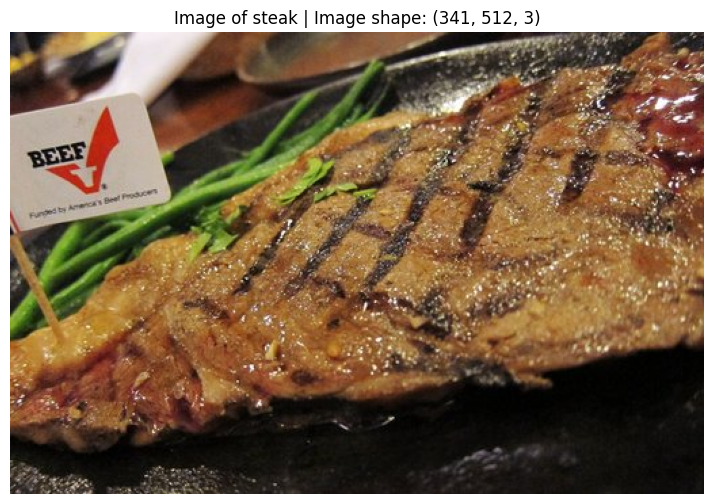

In [71]:
plt.figure(figsize=(10,6))
plt.imshow(img)
plt.axis(False)
plt.title(f"Image of {image_class} | Image shape: {img_as_array.shape}")
plt.show()

Careful that the shape here is `(HxZxC)` so color channel last whereas PyTorch is color channel first !!! so we need to deal with that later on